# NormBank Cleaning

This notebook inspects the NormBank raw file, visualizes label/split balance,
standardizes the schema, and prepares the processed outputs.


In [ ]:
# =========================================================
# CELL PURPOSE:
# Import required libraries, configure notebook display/plotting
# options, define reusable utility functions, and initialise
# project paths for the NormBank cleaning workflow.
#
# RUN IMPACT:
# Cheap — mostly imports, configuration, and helper definitions.
# =========================================================

from __future__ import annotations


# =========================================================
# STEP 1: STANDARD LIBRARY IMPORTS
# ---------------------------------------------------------
# Import core Python utilities used for:
# - filesystem/path handling
# - safe literal parsing
# - CSV and JSON writing
# - hashing for duplicate detection
# - regular expressions for text cleaning/parsing
# - file operations such as copying/moving when needed
# =========================================================
from pathlib import Path
from ast import literal_eval
import csv
import hashlib
import json
import re
import shutil


# =========================================================
# STEP 2: VISUALISATION IMPORTS
# ---------------------------------------------------------
# Import plotting libraries for:
# - exploratory data inspection
# - label distribution plots
# - text-length distribution plots
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# STEP 3: CORE DATAFRAME DEPENDENCY
# ---------------------------------------------------------
# pandas is required for the cleaning workflow.
# Raise a clear runtime error if it is unavailable so the
# notebook fails early with an interpretable message.
# =========================================================
try:
    import pandas as pd
except Exception as exc:
    raise RuntimeError("pandas is required to use this cleaning notebook.") from exc


# =========================================================
# STEP 4: NOTEBOOK DISPLAY HELPER
# ---------------------------------------------------------
# display() is used for rich notebook rendering of DataFrames.
# =========================================================
from IPython.display import display


# =========================================================
# STEP 5: OPTIONAL PARQUET SUPPORT
# ---------------------------------------------------------
# Attempt to import pyarrow parquet support.
# If unavailable, set pq = None so downstream code can
# conditionally handle parquet-based inputs without crashing.
# =========================================================
try:
    import pyarrow.parquet as pq
except Exception:
    pq = None


# =========================================================
# STEP 6: NOTEBOOK-WIDE DISPLAY AND PLOT SETTINGS
# ---------------------------------------------------------
# Configure:
# - seaborn whitegrid theme for cleaner charts
# - wider column display for easier inspection
# - longer text preview before truncation
# =========================================================
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)


# =========================================================
# STEP 7: PROJECT ROOT DETECTION
# ---------------------------------------------------------
# Walk upward from the current working directory until a folder
# containing either "Data" or "data" is found.
#
# Why:
# This makes the notebook more portable across environments,
# since it does not rely on a hardcoded absolute path.
#
# Return:
# - the first matching parent directory
# - otherwise the current working directory as fallback
# =========================================================
def find_project_root() -> Path:
    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (candidate / "Data").exists() or (candidate / "data").exists():
            return candidate
    return Path.cwd().resolve()


# =========================================================
# STEP 8: DEFINE PROJECT PATHS
# ---------------------------------------------------------
# ROOT:
#   Base project folder inferred by find_project_root()
#
# DATA_ROOT:
#   Supports both "Data" and "data" naming conventions
#
# RAW_DIR:
#   Location of raw NormBank input files
#
# OUT_DIR:
#   Destination for cleaned/processed outputs
#
# SAVE_OUTPUTS:
#   Write-control flag for preview vs persistence mode
# =========================================================
ROOT = find_project_root()
DATA_ROOT = ROOT / "Data" if (ROOT / "Data").exists() else ROOT / "data"
RAW_DIR = DATA_ROOT / "raw/normbank"
OUT_DIR = DATA_ROOT / "processed" / "normbank"
SAVE_OUTPUTS = False


# =========================================================
# STEP 9: PRINT PATH CONFIGURATION
# ---------------------------------------------------------
# Print resolved paths and save mode so it is immediately clear
# which folders the notebook is reading from and writing to.
# This is useful for debugging environment/path issues.
# =========================================================
print("Project root:", ROOT)
print("Raw dir:", RAW_DIR)
print("Output dir:", OUT_DIR)
print("SAVE_OUTPUTS:", SAVE_OUTPUTS)


# =========================================================
# STEP 10: DIRECTORY CREATION HELPER
# ---------------------------------------------------------
# Ensure a directory exists before writing outputs.
#
# parents=True:
#   create missing parent folders as needed
#
# exist_ok=True:
#   do not raise an error if the folder already exists
# =========================================================
def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


# =========================================================
# STEP 11: CSV NORMALISATION HELPER
# ---------------------------------------------------------
# Convert values into forms that can be safely written to CSV.
#
# Rules:
# - None -> empty string
# - dict/list -> JSON string so structure is preserved
# - otherwise return value unchanged
#
# Why:
# CSV is flat, so nested Python objects must be serialised first.
# =========================================================
def normalize_for_csv(value):
    if value is None:
        return ""
    if isinstance(value, (dict, list)):
        return json.dumps(value, ensure_ascii=False)
    return value


# =========================================================
# STEP 12: JSONL WRITER
# ---------------------------------------------------------
# Write a sequence of row dictionaries to newline-delimited JSON.
#
# Why JSONL:
# - convenient for ML/data pipelines
# - one JSON object per line
# - easy to stream and inspect
# =========================================================
def write_jsonl(path: Path, rows) -> None:
    ensure_dir(path.parent)
    with path.open("w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")


# =========================================================
# STEP 13: CSV WRITER
# ---------------------------------------------------------
# Write a sequence of row dictionaries to CSV.
#
# Behaviour:
# - creates output directory if needed
# - returns immediately if rows is empty
# - infers field order if fieldnames are not supplied
# - normalises values before writing to handle nested objects
#
# Fieldname inference:
# Preserves first-seen key order across all rows.
# =========================================================
def write_csv(path: Path, rows, fieldnames=None) -> None:
    ensure_dir(path.parent)

    # Skip writing if there is no data to persist
    if not rows:
        return

    # Infer header order dynamically if not explicitly provided
    if fieldnames is None:
        fieldnames = []
        seen = set()
        for row in rows:
            for key in row:
                if key not in seen:
                    seen.add(key)
                    fieldnames.append(key)

    # Write header and row values to CSV
    with path.open("w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in rows:
            writer.writerow({k: normalize_for_csv(row.get(k)) for k in fieldnames})


# =========================================================
# STEP 14: COUNT PLOT HELPER
# ---------------------------------------------------------
# Plot the top-N most frequent values in a Series.
#
# Processing steps:
# - replace missing values with "<missing>"
# - cast everything to string for stable counting
# - compute value counts
# - display top N categories
#
# Typical uses:
# - split distribution
# - task distribution
# - label frequency
# =========================================================
def plot_count(series, title: str, top_n: int = 15):
    counts = series.fillna("<missing>").astype(str).value_counts().head(top_n)

    # Handle empty inputs gracefully
    if counts.empty:
        print(f"No values available for {title}")
        return

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(x=counts.index, y=counts.values, ax=ax, color="#4C72B0")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("count")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()


# =========================================================
# STEP 15: TEXT-LENGTH DISTRIBUTION HELPER
# ---------------------------------------------------------
# Plot a histogram of text lengths measured in characters.
#
# Processing steps:
# - fill missing text with empty strings
# - cast values to string
# - compute character length
# - visualise length distribution
#
# Typical uses:
# - detect unusually short/empty text
# - inspect long-tail outliers
# - compare text distributions across sources/tasks
# =========================================================
def plot_text_length(series, title: str):
    lengths = series.fillna("").astype(str).str.len()

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(lengths, bins=30, ax=ax, color="#55A868")
    ax.set_title(title)
    ax.set_xlabel("characters")
    plt.tight_layout()
    plt.show()

Project root: C:\Users\Ling Jun\Desktop\PSB\AI-ethics
Raw dir: C:\Users\Ling Jun\Desktop\PSB\AI-ethics\Data\raw\normbank
Output dir: C:\Users\Ling Jun\Desktop\PSB\AI-ethics\Data\processed\normbank
SAVE_OUTPUTS: False


In [ ]:
# =========================================================
# CELL PURPOSE:
# Discover available raw NormBank files, load them into a
# single consolidated DataFrame, and perform an initial
# structural inspection of shape, sample rows, and missingness.
#
# RUN IMPACT:
# Moderate — depends on number and size of CSV/parquet files.
# =========================================================


# =========================================================
# STEP 1: DISCOVER INPUT FILES
# ---------------------------------------------------------
# Search the raw input directory for:
# - parquet files
# - CSV files
#
# Files are sorted to ensure deterministic load order.
# This improves reproducibility when concatenating multiple files.
# =========================================================
parquet_files = sorted(RAW_DIR.glob("*.parquet"))
csv_files = sorted(RAW_DIR.glob("*.csv"))


# =========================================================
# STEP 2: LOAD PARQUET INPUTS IF AVAILABLE
# ---------------------------------------------------------
# Prefer parquet when present, since it usually preserves schema
# and types more reliably than CSV.
#
# Logic:
# - if parquet files exist, require pyarrow support
# - read each parquet file into a pandas DataFrame
# - concatenate all files into one unified DataFrame
#
# Metadata handling:
# - "source_file" is derived from the existing split column if present,
#   otherwise defaults to "parquet"
# - "split" is preserved if it exists, otherwise created as empty string
# =========================================================
if parquet_files:
    if pq is None:
        raise RuntimeError("pyarrow is required to read parquet files.")

    raw_df = pd.concat(
        [pq.read_table(path).to_pandas() for path in parquet_files],
        ignore_index=True
    )

    raw_df["source_file"] = raw_df.get("split", "parquet")
    raw_df["split"] = raw_df.get("split", "")


# =========================================================
# STEP 3: FALL BACK TO CSV INPUTS
# ---------------------------------------------------------
# If no parquet files are found, load CSV files instead.
#
# Logic:
# - read each CSV into a DataFrame
# - attach its filename as "source_file" for provenance tracking
# - concatenate all CSV inputs into one unified DataFrame
# =========================================================
elif csv_files:
    raw_df = pd.concat(
        [pd.read_csv(path).assign(source_file=path.name) for path in csv_files],
        ignore_index=True
    )


# =========================================================
# STEP 4: FAIL EARLY IF NO INPUT FILES EXIST
# ---------------------------------------------------------
# Raise a clear error if neither CSV nor parquet inputs are found.
# This prevents silent failures later in the notebook.
# =========================================================
else:
    raise FileNotFoundError(f"No CSV or parquet files found under {RAW_DIR}")


# =========================================================
# STEP 5: BASIC LOAD VALIDATION
# ---------------------------------------------------------
# Print the overall DataFrame shape so it is immediately clear
# how many rows and columns were loaded.
# =========================================================
print("Raw shape:", raw_df.shape)


# =========================================================
# STEP 6: PREVIEW RAW DATA
# ---------------------------------------------------------
# Display the first few rows for a quick manual inspection of:
# - column names
# - data format
# - obvious schema issues
# =========================================================
display(raw_df.head())


# =========================================================
# STEP 7: COLUMN-LEVEL MISSINGNESS SUMMARY
# ---------------------------------------------------------
# Build a compact table showing:
# - each column name
# - number of missing values in that column
#
# Sort descending by missing count so the most incomplete
# columns are reviewed first.
# =========================================================
display(
    pd.DataFrame({
        "column": raw_df.columns,
        "missing": raw_df.isna().sum().values
    }).sort_values("missing", ascending=False)
)

Raw shape: (155423, 10)


,setting,behavior,setting-behavior,constraints,constraints_given,constraint_predict,norm,label,split,source_file
0,construction site,make sexual innuendos,construction site [BEHAVIOR] make sexual innuendos,[OTHER]'s characteristic is 'uncomfortable' [AND] [OTHER]'s gender is 'woman' [AND] [PERSON]'s role is 'construction...,[OTHER]'s gender is 'woman' [AND] [OTHER]'s characteristic is 'uncomfortable' [AND],[PERSON]'s role is 'construction worker',taboo,0,train,NormBank.csv
1,cafe,talk about sex,cafe [BEHAVIOR] talk about sex,[PERSON]'s role is 'barista',[AND],[PERSON]'s role is 'barista',taboo,0,train,NormBank.csv
2,cemetery,pick flowers,cemetery [BEHAVIOR] pick flowers,[PERSON]'s role is 'cemetery salesperson',[AND],[PERSON]'s role is 'cemetery salesperson',taboo,0,test,NormBank.csv
3,banquet hall,have long hair,banquet hall [BEHAVIOR] have long hair,[PERSON]'s gender is 'woman',[AND],[PERSON]'s gender is 'woman',expected,2,train,NormBank.csv
4,arena,drink beer,arena [BEHAVIOR] drink beer,[PERSON]'s role is 'player',[AND],[PERSON]'s role is 'player',taboo,0,test,NormBank.csv


,column,missing
0,setting,0
1,behavior,0
2,setting-behavior,0
3,constraints,0
4,constraints_given,0
5,constraint_predict,0
6,norm,0
7,label,0
8,split,0
9,source_file,0


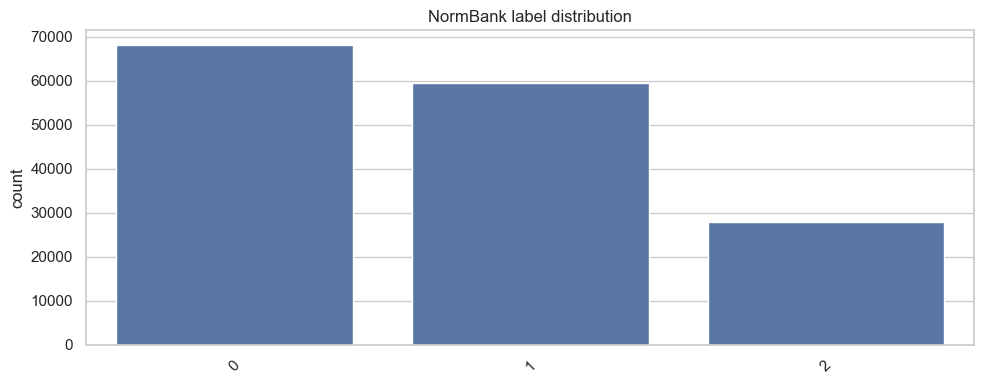

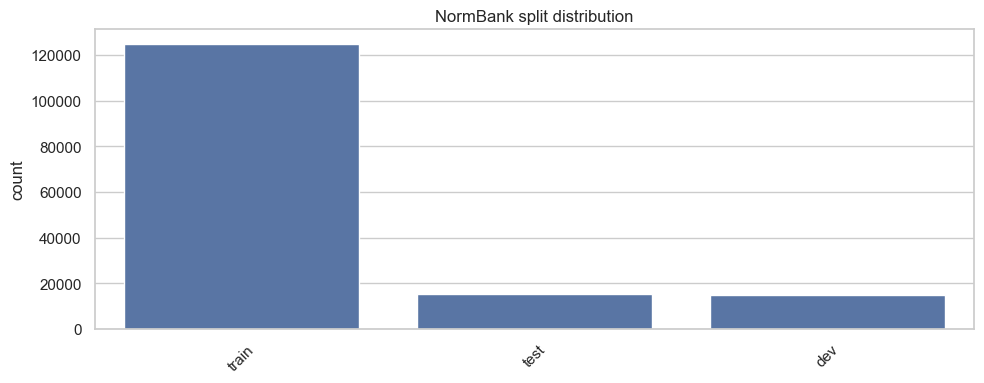

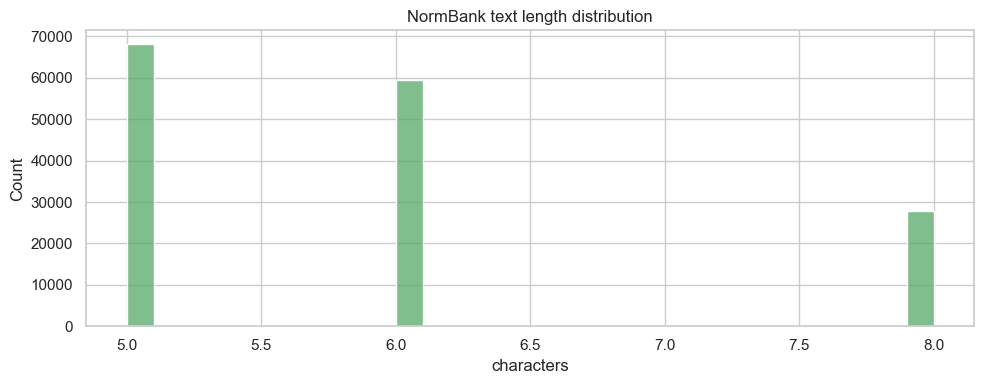

,blank_text,blank_label,blank_split
0,0,0,0


In [ ]:
# =========================================================
# CELL PURPOSE:
# Extract key analysis fields from the raw NormBank dataset,
# visualise basic distributions, and quantify blank values
# for text, labels, and split assignments.
#
# RUN IMPACT:
# Cheap — simple column extraction, plotting, and summary counts.
# =========================================================


# =========================================================
# STEP 1: EXTRACT PRIMARY TEXT COLUMN
# ---------------------------------------------------------
# Build a unified text series for downstream inspection.
#
# Priority order:
# 1. "norm"
# 2. "setting-behavior"
# 3. empty string Series if neither exists
#
# Cleaning applied:
# - replace missing values with empty string
# - cast to string for consistency
# - strip surrounding whitespace
#
# Why:
# NormBank variants may store the main textual content under
# slightly different column names, so this fallback logic
# makes the notebook more robust across file versions.
# =========================================================
text_series = (
    raw_df.get("norm", raw_df.get("setting-behavior", pd.Series(dtype=str)))
    .fillna("")
    .astype(str)
    .str.strip()
)


# =========================================================
# STEP 2: EXTRACT LABEL COLUMN
# ---------------------------------------------------------
# Build a cleaned label series.
#
# Cleaning applied:
# - replace missing values with empty string
# - cast to string
# - strip surrounding whitespace
#
# Why:
# Ensures label values are comparable and safe for counting.
# =========================================================
label_series = (
    raw_df.get("label", pd.Series(dtype=str))
    .fillna("")
    .astype(str)
    .str.strip()
)


# =========================================================
# STEP 3: EXTRACT SPLIT COLUMN
# ---------------------------------------------------------
# Build a cleaned split series (e.g., train / test / validation).
#
# Cleaning applied:
# - replace missing values with empty string
# - cast to string
# - strip surrounding whitespace
#
# Why:
# This allows consistent inspection of split coverage even if
# some rows are incomplete or the column is partially missing.
# =========================================================
split_series = (
    raw_df.get("split", pd.Series(dtype=str))
    .fillna("")
    .astype(str)
    .str.strip()
)


# =========================================================
# STEP 4: PLOT LABEL DISTRIBUTION
# ---------------------------------------------------------
# Visualise the frequency of non-blank labels.
#
# Note:
# Blank labels are excluded here because the purpose of this
# chart is to show the actual class distribution, not missingness.
# =========================================================
plot_count(
    label_series[label_series != ""],
    "NormBank label distribution"
)


# =========================================================
# STEP 5: PLOT SPLIT DISTRIBUTION
# ---------------------------------------------------------
# Visualise the distribution of split values.
#
# Blank splits are explicitly replaced with "<blank>" so missing
# assignments remain visible in the chart rather than disappearing.
# =========================================================
plot_count(
    split_series.replace("", "<blank>"),
    "NormBank split distribution"
)


# =========================================================
# STEP 6: PLOT TEXT LENGTH DISTRIBUTION
# ---------------------------------------------------------
# Visualise the distribution of text lengths in characters.
#
# Why:
# Helps identify:
# - empty or near-empty rows
# - unusually short texts
# - extreme long-text outliers
# =========================================================
plot_text_length(
    text_series,
    "NormBank text length distribution"
)


# =========================================================
# STEP 7: SUMMARISE BLANK FIELD COUNTS
# ---------------------------------------------------------
# Build a compact one-row DataFrame showing the number of rows
# with blank values for:
# - text
# - label
# - split
#
# Why:
# This provides a quick quality check before cleaning or filtering.
# =========================================================
display(
    pd.DataFrame({
        "blank_text": [int((text_series == "").sum())],
        "blank_label": [int((label_series == "").sum())],
        "blank_split": [int((split_series == "").sum())],
    })
)

Cleaned shape: (155423, 7)


,text,label,dataset,task,split,source_file,metadata
0,taboo,0,normbank,norm_classification,train,NormBank.csv,"{'setting': 'construction site', 'behavior': 'make sexual innuendos', 'constraints': '[OTHER]'s characteristic is 'u..."
1,taboo,0,normbank,norm_classification,train,NormBank.csv,"{'setting': 'cafe', 'behavior': 'talk about sex', 'constraints': '[PERSON]'s role is 'barista'', 'constraints_given'..."
2,taboo,0,normbank,norm_classification,test,NormBank.csv,"{'setting': 'cemetery', 'behavior': 'pick flowers', 'constraints': '[PERSON]'s role is 'cemetery salesperson'', 'con..."
3,expected,2,normbank,norm_classification,train,NormBank.csv,"{'setting': 'banquet hall', 'behavior': 'have long hair', 'constraints': '[PERSON]'s gender is 'woman'', 'constraint..."
4,taboo,0,normbank,norm_classification,test,NormBank.csv,"{'setting': 'arena', 'behavior': 'drink beer', 'constraints': '[PERSON]'s role is 'player'', 'constraints_given': ' ..."


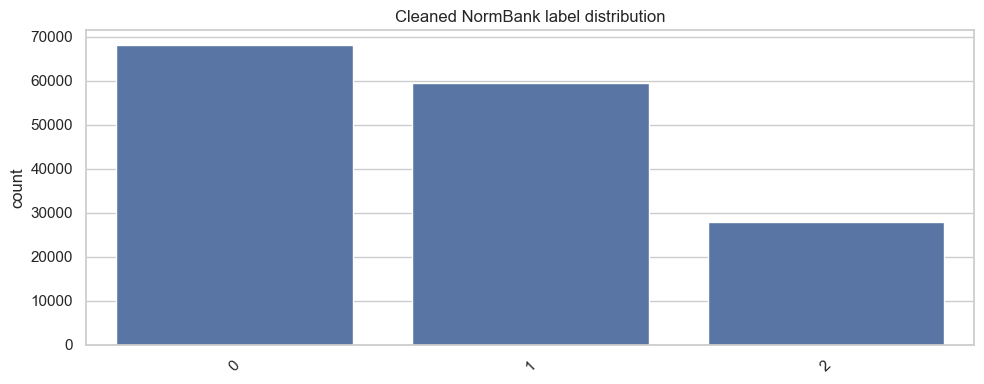

In [ ]:
# =========================================================
# CELL PURPOSE:
# Construct the final cleaned NormBank dataset in a standardised
# schema, preserve non-core fields as metadata, and perform
# a quick post-cleaning validation of shape, preview rows,
# and label distribution.
#
# RUN IMPACT:
# Cheap to moderate — DataFrame construction plus metadata
# serialisation across all rows.
# =========================================================


# =========================================================
# STEP 1: BUILD STANDARDISED CLEANED DATAFRAME
# ---------------------------------------------------------
# Create the final cleaned dataset using a unified schema:
# - text
# - label
# - dataset
# - task
# - split
# - source_file
#
# Text field logic:
# - prefer "norm"
# - fall back to "setting-behavior"
#
# Cleaning applied to text/label/split:
# - replace missing values with empty string
# - cast to string
# - strip surrounding whitespace
#
# Fixed columns:
# - dataset = "normbank"
# - task = "norm_classification"
#
# Why:
# This standardised format makes the dataset easier to combine
# with other benchmarks in a shared downstream pipeline.
# =========================================================
cleaned_df = pd.DataFrame({
    "text": raw_df.get("norm", raw_df.get("setting-behavior", "")).fillna("").astype(str).str.strip(),
    "label": raw_df.get("label", "").fillna("").astype(str).str.strip(),
    "dataset": "normbank",
    "task": "norm_classification",
    "split": raw_df.get("split", "").fillna("").astype(str).str.strip(),
    "source_file": raw_df["source_file"].astype(str),
})


# =========================================================
# STEP 2: IDENTIFY NON-CORE COLUMNS FOR METADATA
# ---------------------------------------------------------
# Collect all columns from the raw dataset that are not part
# of the cleaned core schema.
#
# Excluded core/raw fields:
# - norm
# - setting-behavior
# - label
# - split
# - source_file
#
# Why:
# These remaining fields may still hold useful provenance or
# contextual information, so they are preserved in metadata
# rather than discarded.
# =========================================================
metadata_cols = [
    c for c in raw_df.columns
    if c not in {"norm", "setting-behavior", "label", "split", "source_file"}
]


# =========================================================
# STEP 3: ATTACH ROW-LEVEL METADATA
# ---------------------------------------------------------
# Convert all non-core columns into a dictionary for each row
# and store them in a single "metadata" column.
#
# Why:
# - preserves auxiliary information without widening the schema
# - keeps the main dataset compact and modelling-friendly
# - supports later auditing or traceability if needed
# =========================================================
cleaned_df["metadata"] = raw_df[metadata_cols].to_dict(orient="records")


# =========================================================
# STEP 4: BASIC CLEANING VALIDATION
# ---------------------------------------------------------
# Print the shape of the cleaned dataset so it is immediately
# clear how many rows and columns are present after restructuring.
# =========================================================
print("Cleaned shape:", cleaned_df.shape)


# =========================================================
# STEP 5: PREVIEW CLEANED OUTPUT
# ---------------------------------------------------------
# Display the first few rows for manual inspection of:
# - schema correctness
# - cleaned text and label fields
# - metadata structure
# =========================================================
display(cleaned_df.head())


# =========================================================
# STEP 6: PLOT CLEANED LABEL DISTRIBUTION
# ---------------------------------------------------------
# Visualise the final label distribution after cleaning.
#
# Why:
# This acts as a quick sanity check for:
# - label preservation
# - class imbalance
# - unexpected blank or malformed label values
# =========================================================
plot_count(
    cleaned_df["label"],
    "Cleaned NormBank label distribution"
)

In [5]:
if SAVE_OUTPUTS:
    write_jsonl(OUT_DIR / "normbank.jsonl", cleaned_df.to_dict(orient="records"))
    write_csv(OUT_DIR / "normbank.csv", cleaned_df.to_dict(orient="records"))
    label_summary = [{"labels": cleaned_df["label"].value_counts().to_dict()}]
    write_jsonl(OUT_DIR / "label_summary.jsonl", label_summary)
    write_csv(OUT_DIR / "label_summary.csv", label_summary)
    print("Wrote cleaned NormBank outputs to", OUT_DIR)
else:
    print("Preview only. Set SAVE_OUTPUTS = True and rerun this cell to write cleaned files.")


Preview only. Set SAVE_OUTPUTS = True and rerun this cell to write cleaned files.
